In [39]:
import os
import shutil

import plt

base_dir = "/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/ColorBlindnessImages/Data"

print("Organizing images into class folders...")

# Loop through all files in the directory
for filename in os.listdir(base_dir):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        # Grab the first character of the filename (the digit label)
        label = filename.split('_')[0]

        # Create a new folder for this label (0-9) if it doesn't exist
        label_dir = os.path.join(base_dir, label)
        if not os.path.exists(label_dir):
            os.makedirs(label_dir)

        # Move the file into its new folder
        src = os.path.join(base_dir, filename)
        dst = os.path.join(label_dir, filename)
        shutil.move(src, dst)

print("Sorting complete! You can now run your Neural Network cell again.")

Organizing images into class folders...
Sorting complete! You can now run your Neural Network cell again.


In [117]:
import tensorflow as tf

# Lock the random seeds
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

print("🔒 Random seeds locked!")

🔒 Random seeds locked!


Loading Data and Executing 70/15/15 Split...
Found 1400 files belonging to 10 classes.
Using 980 files for training.
Found 1400 files belonging to 10 classes.
Using 420 files for validation.

✅ Data successfully split!
Training batches: 31
Validation batches: 7
Test batches: 7
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


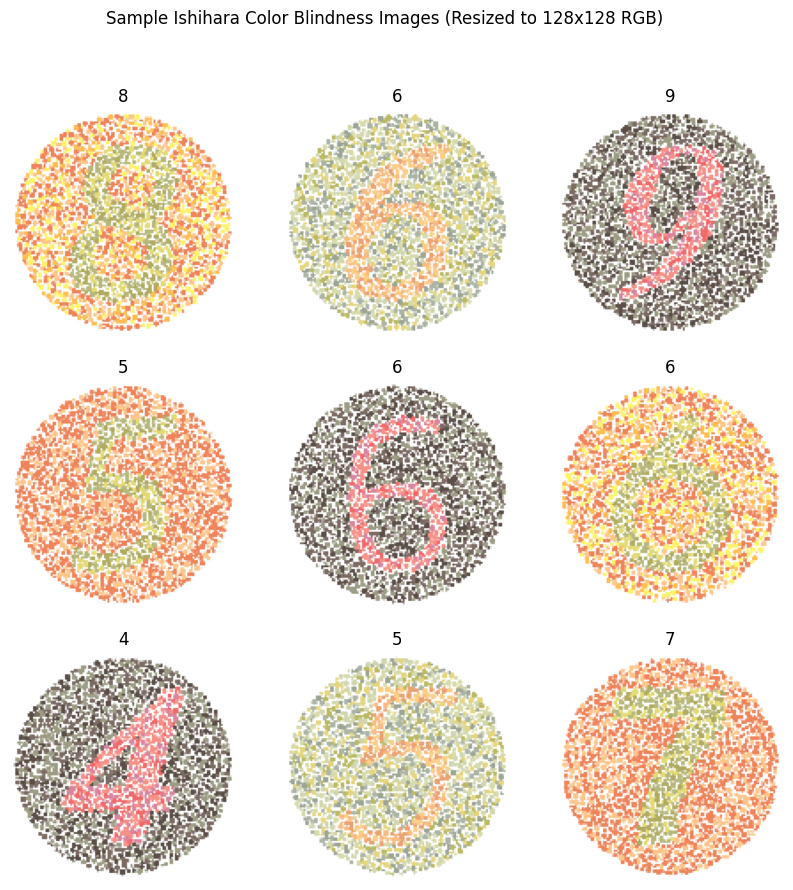

In [118]:
import tensorflow as tf

# --- 1. SETUP PARAMETERS ---
data_dir = '/Users/alinakatiliute/university/BIM RSM/Deep Learning Python/ColorBlindnessImages/data'
batch_size = 32
img_height = 128
img_width = 128

print("Loading Data and Executing 70/15/15 Split...")

# --- 2. EXTRACT 70% FOR TRAINING ---
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

# --- 3. EXTRACT 30% FOR THE VAL/TEST POOL ---
val_test_pool = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

# --- 4. SPLIT THE POOL IN HALF (15% Val / 15% Test) ---
val_test_batches = tf.data.experimental.cardinality(val_test_pool)
test_batches = val_test_batches // 2

test_ds = val_test_pool.take(test_batches)
val_ds = val_test_pool.skip(test_batches)

print("\n✅ Data successfully split!")

print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

# --- Visualizing the Data ---
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # The images are loaded as floats, we cast them back to integers to plot them safely
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample Ishihara Color Blindness Images (Resized to 128x128 RGB)")
plt.show()

--- Class Distribution Check ---
Digit 0: 128 images
Digit 1: 140 images
Digit 2: 144 images
Digit 3: 152 images
Digit 4: 132 images
Digit 5: 156 images
Digit 6: 132 images
Digit 7: 140 images
Digit 8: 148 images
Digit 9: 128 images
--- Plotting Original Class Distribution ---


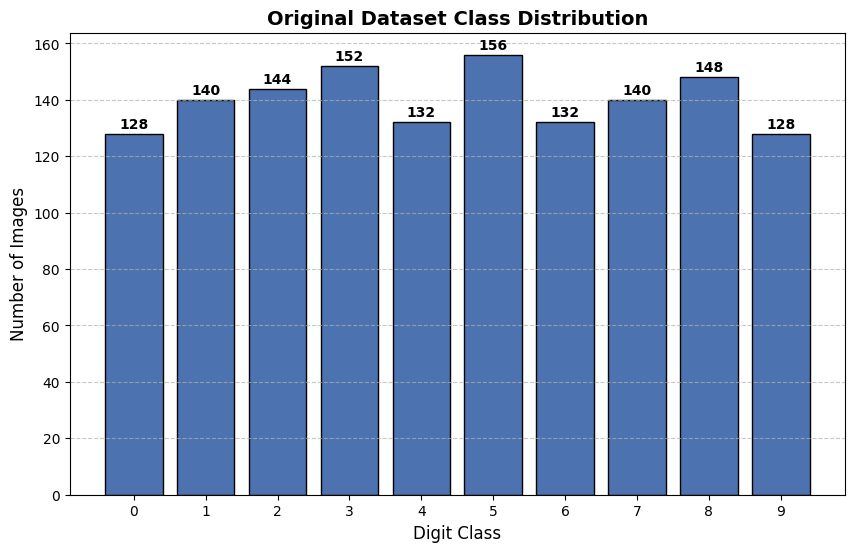

In [70]:
import os
import os
import matplotlib.pyplot as plt

print("--- Class Distribution Check ---")
for i in range(10):
    folder_path = os.path.join(data_dir, str(i))
    if os.path.exists(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg'))])
        print(f"Digit {i}: {count} images")


print("--- Plotting Original Class Distribution ---")

# The data you already counted
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
class_counts = [128, 140, 144, 152, 132, 156, 132, 140, 148, 128]

plt.figure(figsize=(10, 6))
# Create the bar chart with a nice aesthetic color
plt.bar(class_names, class_counts, color='#4C72B0', edgecolor='black')

plt.title('Original Dataset Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Digit Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(class_names)

# Add a subtle grid behind the bars for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact numbers on top of each bar!
for i, count in enumerate(class_counts):
    plt.text(i, count + 2, str(count), ha='center', fontweight='bold')

plt.show()

### Building the Baseline CNN Model

--- BUILDING BASELINE MODEL ---


Model: "sequential_71"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_71 (Rescaling)    (None, 128, 128, 3)       0         
                                                                 
 conv2d_151 (Conv2D)         (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d_151 (MaxPool  (None, 63, 63, 16)        0         
 ing2D)                                                          
                                                                 
 conv2d_152 (Conv2D)         (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_152 (MaxPool  (None, 30, 30, 32)        0         
 ing2D)                                                          
                                                                 
 flatten_71 (Flatten)        (None, 28800)           

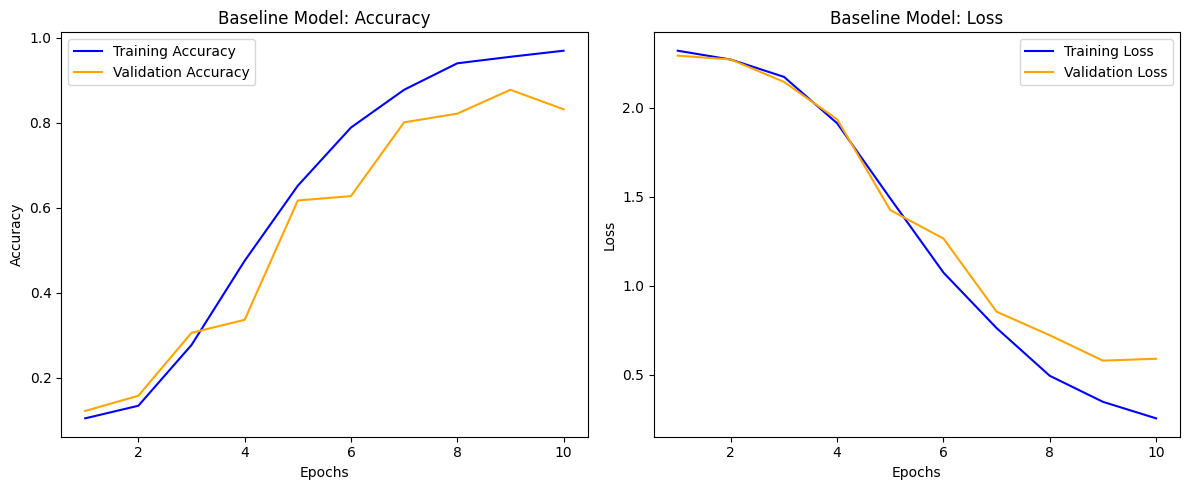

In [138]:
import time
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

print("--- BUILDING BASELINE MODEL ---")

# 1. Define the Architecture
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 2. Compile the Model
baseline_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# 3. Train the Model and Track Time
print("\n🚀 Starting Baseline Training...")
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

elapsed_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Baseline Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Baseline Peak Val Accuracy: {max(history_baseline.history['val_accuracy']):.4f}")

# --- 4. GENERATE THE PLOT AUTOMATICALLY ---
print("\n📊 Generating Plots...")
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Baseline Model: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Baseline Model: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Experiment 1: Adding a 3rd Convolutional Layer

In [137]:
import time
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

print("--- BUILDING BASELINE MODEL ---")

# 1. Define the Architecture
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu', padding = "same"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), activation='relu', padding = "same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 2. Compile the Model
baseline_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# 3. Train the Model and Track Time
print("\n🚀 Starting Baseline Training...")
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

elapsed_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Baseline Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Baseline Peak Val Accuracy: {max(history_baseline.history['val_accuracy']):.4f}")

--- BUILDING BASELINE MODEL ---


Model: "sequential_70"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_70 (Rescaling)    (None, 128, 128, 3)       0         
                                                                 
 conv2d_149 (Conv2D)         (None, 128, 128, 16)      448       
                                                                 
 max_pooling2d_149 (MaxPool  (None, 64, 64, 16)        0         
 ing2D)                                                          
                                                                 
 conv2d_150 (Conv2D)         (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_150 (MaxPool  (None, 32, 32, 32)        0         
 ing2D)                                                          
                                                                 
 flatten_70 (Flatten)        (None, 32768)           

### Experiemnt 2

--- EXPERIMENT 2.1: DEPTH + DROPOUT ---


Model: "sequential_45"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_45 (Rescaling)    (None, 128, 128, 3)       0         
                                                                 
 conv2d_98 (Conv2D)          (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d_98 (MaxPooli  (None, 63, 63, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_99 (Conv2D)          (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_99 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_100 (Conv2D)         (None, 28, 28, 64)      

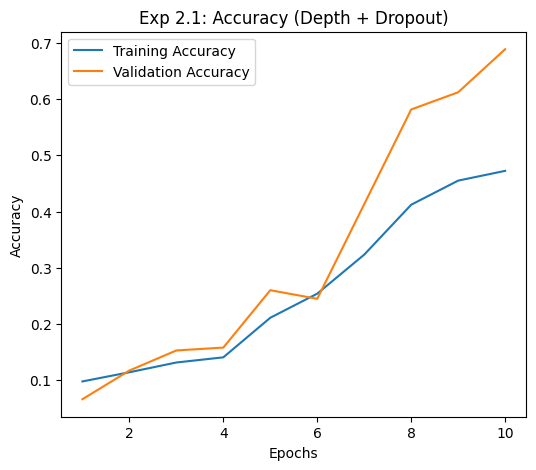

In [86]:
import time
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

print("--- EXPERIMENT 2.1: DEPTH + DROPOUT ---")

# Keeping the seed locked for consistency
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

model_exp2_1 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # 3 Conv Layers (from Experiment 1)
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # Dense layer with 64 neurons
    layers.Dense(64, activation='relu'),

    # THE ADDITION: Dropout layer to prevent overfitting
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

model_exp2_1.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_exp2_1.summary()

print("\n🚀 Starting Experiment 2.1 Training...")
start_time = time.time() # Using system time as requested by rubric [cite: 99, 106]
history_exp2_1 = model_exp2_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)
elapsed_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Exp 2.1 Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Exp 2.1 Peak Val Accuracy: {max(history_exp2_1.history['val_accuracy']):.4f}")

# Plotting results for the report [cite: 81]
acc = history_exp2_1.history['accuracy']
val_acc = history_exp2_1.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(6, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Exp 2.1: Accuracy (Depth + Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Experiment 1: Loss (Increased Depth)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

plt.legend()
plt.show()

📊 Generating Experiment 2 Plots (Depth + Dropout)...


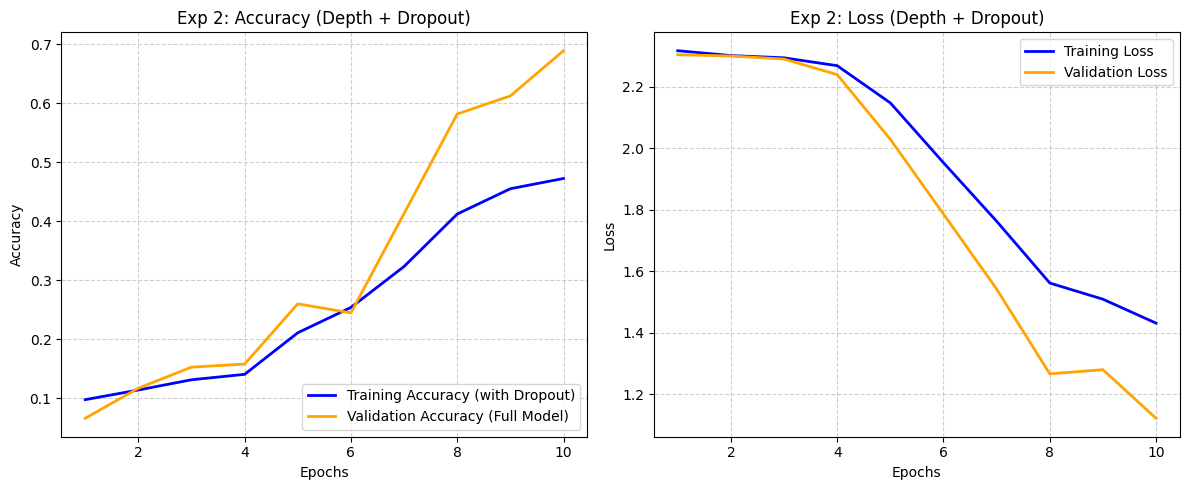

In [90]:
import matplotlib.pyplot as plt

# Verify we have the data before plotting
if 'history_exp2_1' in globals():
    print("📊 Generating Experiment 2 Plots (Depth + Dropout)...")

    # Grab data from the history object
    acc = history_exp2_1.history['accuracy']
    val_acc = history_exp2_1.history['val_accuracy']
    loss = history_exp2_1.history['loss']
    val_loss = history_exp2_1.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy (with Dropout)', color='blue', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy (Full Model)', color='orange', linewidth=2)
    plt.title('Exp 2: Accuracy (Depth + Dropout)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    plt.title('Exp 2: Loss (Depth + Dropout)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("❌ Error: 'history_exp2_1' not found in memory. Did you rename the variable or restart the kernel?")

### Experiment 3: Increasing Neurons in the Dense Layer to 256

In [139]:
# --- EXPERIMENT 3: WIDER (256 Neurons) ---
# Lock the seed before building the model!
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

model_exp3 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    # THE EXPERIMENT: Increase from 64 to 256 neurons
    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model_exp3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Starting Experiment 3 Training...")
start_time = time.time()
history_exp3 = model_exp3.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)
elapsed_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Exp 3 Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Exp 3 Peak Val Accuracy: {max(history_exp3.history['val_accuracy']):.4f}")


🚀 Starting Experiment 3 Training...
Epoch 1/10
31/31 [==============================] - 5s 133ms/step - loss: 2.4742 - accuracy: 0.1173 - val_loss: 2.3166 - val_accuracy: 0.1173
Epoch 2/10
31/31 [==============================] - 4s 137ms/step - loss: 2.3009 - accuracy: 0.1071 - val_loss: 2.2967 - val_accuracy: 0.1020
Epoch 3/10
31/31 [==============================] - 4s 140ms/step - loss: 2.2730 - accuracy: 0.1673 - val_loss: 2.2814 - val_accuracy: 0.0867
Epoch 4/10
31/31 [==============================] - 5s 142ms/step - loss: 2.1995 - accuracy: 0.2112 - val_loss: 2.2093 - val_accuracy: 0.1429
Epoch 5/10
31/31 [==============================] - 4s 109ms/step - loss: 2.0432 - accuracy: 0.3235 - val_loss: 2.0899 - val_accuracy: 0.2551
Epoch 6/10
31/31 [==============================] - 4s 114ms/step - loss: 1.8013 - accuracy: 0.4786 - val_loss: 1.8464 - val_accuracy: 0.4388
Epoch 7/10
31/31 [==============================] - 4s 118ms/step - loss: 1.4730 - accuracy: 0.6827 - val_loss:

📊 Generating Experiment 3 Plots...


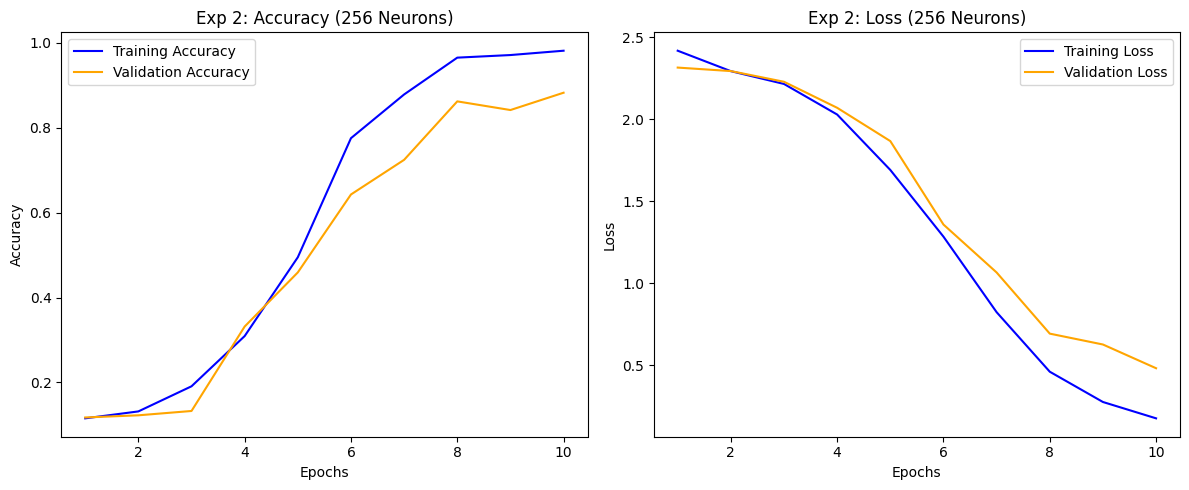

In [122]:
import matplotlib.pyplot as plt

print("📊 Generating Experiment 3 Plots...")

# Grab data from the history_exp3 object
acc = history_exp3.history['accuracy']
val_acc = history_exp3.history['val_accuracy']
loss = history_exp3.history['loss']
val_loss = history_exp3.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Exp 2: Accuracy (256 Neurons)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Exp 2: Loss (256 Neurons)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [89]:
# --- Automating the "Sweet Spot" ---
# 1. Find the highest validation accuracy in the list
best_val_acc = max(history_exp2.history['val_accuracy'])

# 2. Find which epoch that accuracy occurred on (we add 1 because Python counts from 0)
best_epoch = history_exp2.history['val_accuracy'].index(best_val_acc) + 1

print(f"\n🏆 The True Accuracy ('Sweet Spot'):")
print(f"Peak Validation Accuracy: {best_val_acc:.4f} (Achieved at Epoch {best_epoch})")


🏆 The True Accuracy ('Sweet Spot'):
Peak Validation Accuracy: 0.9439 (Achieved at Epoch 9)


### Experiment 4:

In [140]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

print("--- EXPERIMENT 4: WIDER + DROPOUT (256 Neurons + 0.3 Dropout) ---")

# Lock the seed
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# 1. Define Architecture
model_exp4 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    # Increased neurons for higher dimensional mapping
    layers.Dense(256, activation='relu'),

    # Dropout to force generalization with the higher neuron count
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

# 2. Compile
model_exp4.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train
print("\n🚀 Starting Experiment 4 Training...")
start_time = time.time()
history_exp4 = model_exp4.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)
elapsed_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Exp 4 Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Exp 4 Peak Val Accuracy: {max(history_exp4.history['val_accuracy']):.4f}")

--- EXPERIMENT 4: WIDER + DROPOUT (256 Neurons + 0.3 Dropout) ---

🚀 Starting Experiment 4 Training...
Epoch 1/10
31/31 [==============================] - 6s 151ms/step - loss: 2.5034 - accuracy: 0.1000 - val_loss: 2.3016 - val_accuracy: 0.1122
Epoch 2/10
31/31 [==============================] - 4s 105ms/step - loss: 2.3000 - accuracy: 0.1153 - val_loss: 2.2930 - val_accuracy: 0.1429
Epoch 3/10
31/31 [==============================] - 4s 119ms/step - loss: 2.2846 - accuracy: 0.1398 - val_loss: 2.2901 - val_accuracy: 0.1224
Epoch 4/10
31/31 [==============================] - 4s 122ms/step - loss: 2.2210 - accuracy: 0.1827 - val_loss: 2.2480 - val_accuracy: 0.1582
Epoch 5/10
31/31 [==============================] - 4s 130ms/step - loss: 2.0718 - accuracy: 0.2643 - val_loss: 2.0586 - val_accuracy: 0.3316
Epoch 6/10
31/31 [==============================] - 10s 337ms/step - loss: 1.7861 - accuracy: 0.4051 - val_loss: 1.7787 - val_accuracy: 0.4133
Epoch 7/10
31/31 [==========================

📊 Generating Experiment 4 Plots...


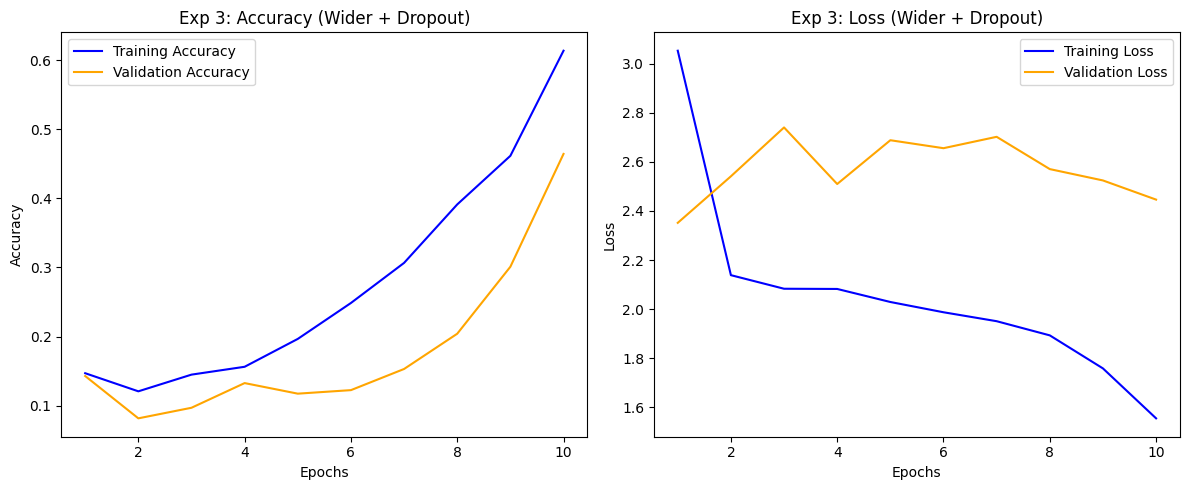

In [124]:
import matplotlib.pyplot as plt

print("📊 Generating Experiment 4 Plots...")

# Grab data from the history_exp4 object
acc = history_exp4.history['accuracy']
val_acc = history_exp4.history['val_accuracy']
loss = history_exp4.history['loss']
val_loss = history_exp4.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Exp 3: Accuracy (Wider + Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Exp 3: Loss (Wider + Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

📊 Rescuing and Generating Exp 4 Plots...


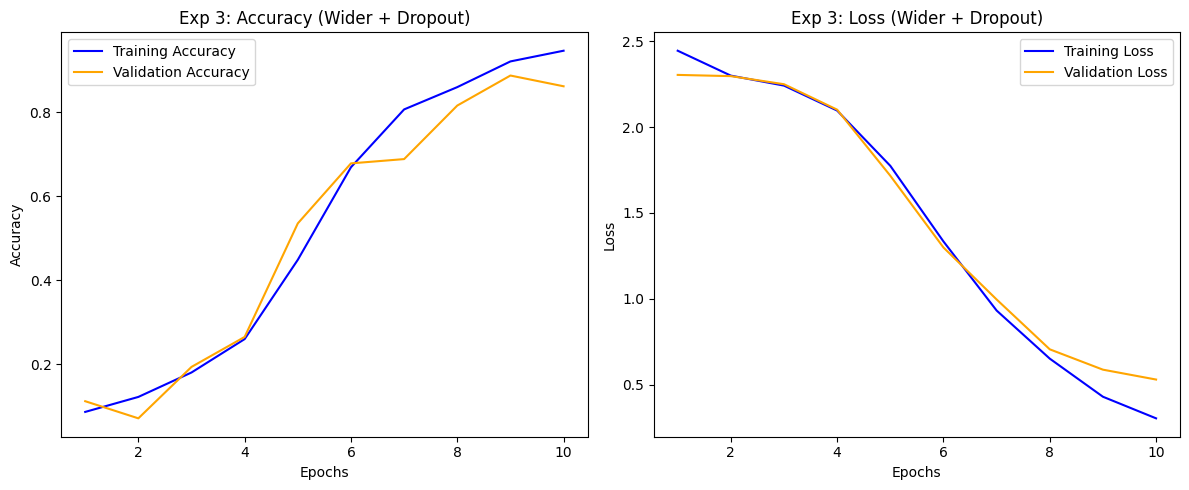

In [126]:
import matplotlib.pyplot as plt

print("📊 Rescuing and Generating Exp 4 Plots...")

# 1. HARDCODE THE EXACT LOG NUMBERS
acc =      [0.0867, 0.1224, 0.1806, 0.2602, 0.4490, 0.6694, 0.8071, 0.8602, 0.9214, 0.9469]
val_acc =  [0.1122, 0.0714, 0.1939, 0.2653, 0.5357, 0.6786, 0.6888, 0.8163, 0.8878, 0.8622]
loss =     [2.4444, 2.2993, 2.2412, 2.0958, 1.7742, 1.3339, 0.9318, 0.6517, 0.4299, 0.3041]
val_loss = [2.3036, 2.2964, 2.2493, 2.1011, 1.7164, 1.2987, 0.9961, 0.7059, 0.5875, 0.5300]

epochs_range = range(1, 11)

# 2. PLOT DIRECTLY FROM THE LISTS
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Exp 3: Accuracy (Wider + Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('Exp 3: Loss (Wider + Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Experiment 5: adding dropout to 2-layer CNN

In [134]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

print("--- EXPERIMENT 5: BASELINE + DROPOUT (64 Neurons + 0.3 Dropout) ---")

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

model_exp5 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    # Back to Baseline width (64)
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

model_exp5.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Starting Experiment 5 Training...")
start_time = time.time()
history_exp5 = model_exp5.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)
elapsed_time = time.time() - start_time

print(f"\n✅ Training Complete!")
print(f"⏱️ Exp 5 Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Exp 5 Peak Val Accuracy: {max(history_exp5.history['val_accuracy']):.4f}")

--- EXPERIMENT 5: BASELINE + DROPOUT (64 Neurons + 0.3 Dropout) ---



🚀 Starting Experiment 5 Training...
Epoch 1/10
31/31 [==============================] - 6s 139ms/step - loss: 2.3433 - accuracy: 0.0867 - val_loss: 2.3024 - val_accuracy: 0.0969
Epoch 2/10
31/31 [==============================] - 3s 98ms/step - loss: 2.3023 - accuracy: 0.1071 - val_loss: 2.3032 - val_accuracy: 0.1122
Epoch 3/10
31/31 [==============================] - 3s 105ms/step - loss: 2.3000 - accuracy: 0.1173 - val_loss: 2.3027 - val_accuracy: 0.0459
Epoch 4/10
31/31 [==============================] - 10s 327ms/step - loss: 2.2822 - accuracy: 0.1388 - val_loss: 2.2863 - val_accuracy: 0.1378
Epoch 5/10
31/31 [==============================] - 5s 156ms/step - loss: 2.2270 - accuracy: 0.1918 - val_loss: 2.2202 - val_accuracy: 0.1429
Epoch 6/10
31/31 [==============================] - 3s 105ms/step - loss: 2.0727 - accuracy: 0.2653 - val_loss: 1.9672 - val_accuracy: 0.2704
Epoch 7/10
31/31 [==============================] - 4s 108ms/step - loss: 1.8553 - accuracy: 0.3143 - val_loss:

📊 Generating Experiment 5 Plots...


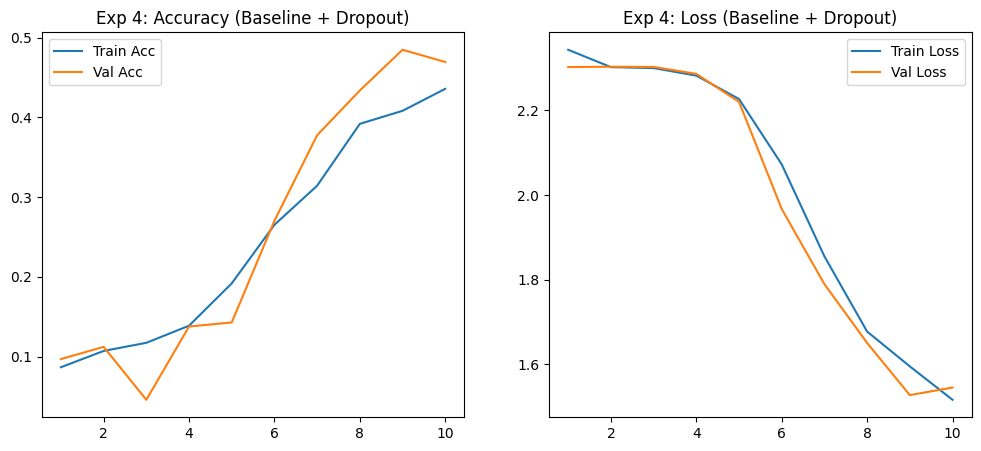

In [136]:
import matplotlib.pyplot as plt

print("📊 Generating Experiment 5 Plots...")
acc = history_exp5.history['accuracy']
val_acc = history_exp5.history['val_accuracy']
loss = history_exp5.history['loss']
val_loss = history_exp5.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.title('Exp 4: Accuracy (Baseline + Dropout)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Exp 4: Loss (Baseline + Dropout)')
plt.legend()
plt.show()

### Testing the Final Model (Experiemnt 4)

--- FINAL STEP: TEST SET EVALUATION & CONFUSION MATRIX ---
✅ Test Accuracy: 0.8438
✅ Test Loss: 0.5469



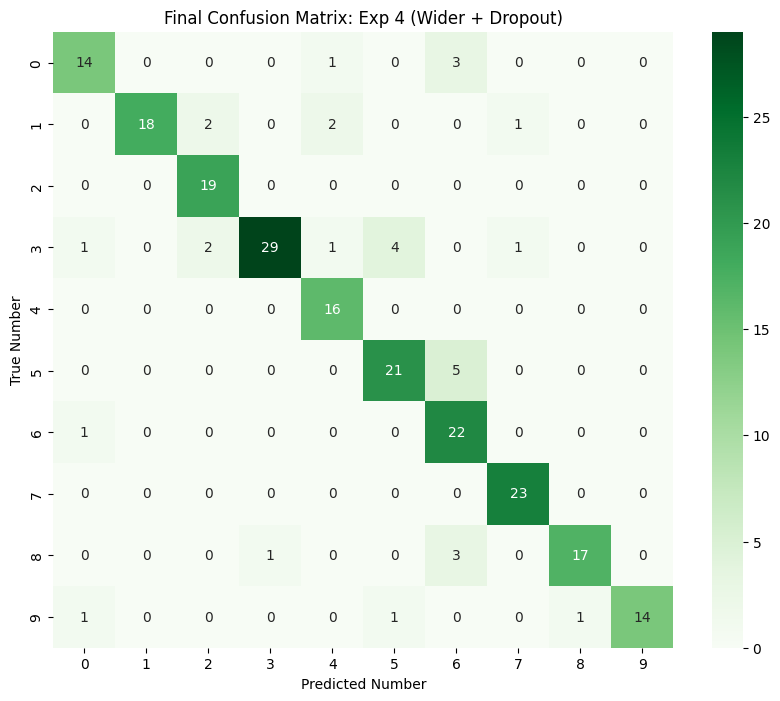


--- Detailed Performance Breakdown ---
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        18
           1       1.00      0.78      0.88        23
           2       0.83      1.00      0.90        19
           3       0.97      0.76      0.85        38
           4       0.80      1.00      0.89        16
           5       0.81      0.81      0.81        26
           6       0.67      0.96      0.79        23
           7       0.92      1.00      0.96        23
           8       0.94      0.81      0.87        21
           9       1.00      0.82      0.90        17

    accuracy                           0.86       224
   macro avg       0.88      0.87      0.87       224
weighted avg       0.88      0.86      0.86       224



In [108]:
%import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("--- FINAL STEP: TEST SET EVALUATION & CONFUSION MATRIX ---")

# 1. Physical Test on unseen data
test_loss, test_acc = model_exp4.evaluate(test_ds, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}\n")

# 2. Collect all predictions and true labels
y_true = []
y_pred = []

for imgs, labels in test_ds:
    # Get model's raw probability output
    preds = model_exp4.predict(imgs, verbose=0)
    # Convert probabilities to the single highest number (0-9)
    y_pred.extend(np.argmax(preds, axis=1))
    # Keep track of what the number actually was
    y_true.extend(labels.numpy())

# 3. Create the Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot the Matrix for the report
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Final Confusion Matrix: Exp 4 (Wider + Dropout)')
plt.xlabel('Predicted Number')
plt.ylabel('True Number')
plt.show()

# 5. Print text breakdown
print("\n--- Detailed Performance Breakdown ---")
print(classification_report(y_true, y_pred))

### Experiment 4: creaing class imbalance

In [109]:
import tensorflow as tf

print("--- Creating an Artificially Imbalanced Training Set ---")

# A function to filter the dataset
def imbalance_filter(image, label):
    # Identify our targeted "minority" classes: digits 0, 1, and 2
    is_minority = tf.reduce_any(tf.equal(label, [0, 1, 2]))

    # Generate a random number between 0.0 and 1.0
    rand_val = tf.random.uniform(shape=[], minval=0., maxval=1.)

    # If it's NOT a minority class, keep it (100%).
    # If it IS a minority class, only keep it if the random number is < 0.10 (10%).
    keep = tf.logical_or(tf.logical_not(is_minority), rand_val < 0.10)
    return keep

# Unbatch the training set, apply the filter to drop images, then re-batch it!
imbalanced_train_ds = train_ds.unbatch().filter(imbalance_filter).batch(BATCH_SIZE)

print("Severe Class Imbalance applied! Digits 0, 1, and 2 are now starving for data.")

--- Creating an Artificially Imbalanced Training Set ---
Severe Class Imbalance applied! Digits 0, 1, and 2 are now starving for data.


--- EXPERIMENT 6 (Part C): Full Fix with Visuals ---
🔍 Scanning dataset to calculate weights...
✅ Weights generated: {0: 14.06, 1: 5.858333333333333, 2: 8.7875, 3: 0.7322916666666667, 4: 0.7898876404494382, 5: 0.6449541284403669, 6: 0.7559139784946236, 7: 0.7559139784946236, 8: 0.6632075471698113, 9: 0.7641304347826087}



🚀 Starting Training...
Epoch 1/10
22/22 [==============================] - 5s 162ms/step - loss: 2.5746 - accuracy: 0.0455 - val_loss: 2.3023 - val_accuracy: 0.1224
Epoch 2/10
22/22 [==============================] - 3s 136ms/step - loss: 2.3107 - accuracy: 0.1027 - val_loss: 2.2917 - val_accuracy: 0.1888
Epoch 3/10
22/22 [==============================] - 3s 126ms/step - loss: 2.5245 - accuracy: 0.0881 - val_loss: 2.3360 - val_accuracy: 0.1071
Epoch 4/10
22/22 [==============================] - 5s 198ms/step - loss: 2.4458 - accuracy: 0.0114 - val_loss: 2.3001 - val_accuracy: 0.1122
Epoch 5/10
22/22 [==============================] - 5s 240ms/step - loss: 2.5140 - accuracy: 0.0469 - val_loss: 2.3004 - val_accuracy: 0.1327
Epoch 6/10
22/22 [==============================] - 4s 154ms/step - loss: 2.3839 - accuracy: 0.0171 - val_loss: 2.3147 - val_accuracy: 0.1020
Epoch 7/10
22/22 [==============================] - 4s 182ms/step - loss: 2.2500 - accuracy: 0.0372 - val_loss: 2.2999 - val

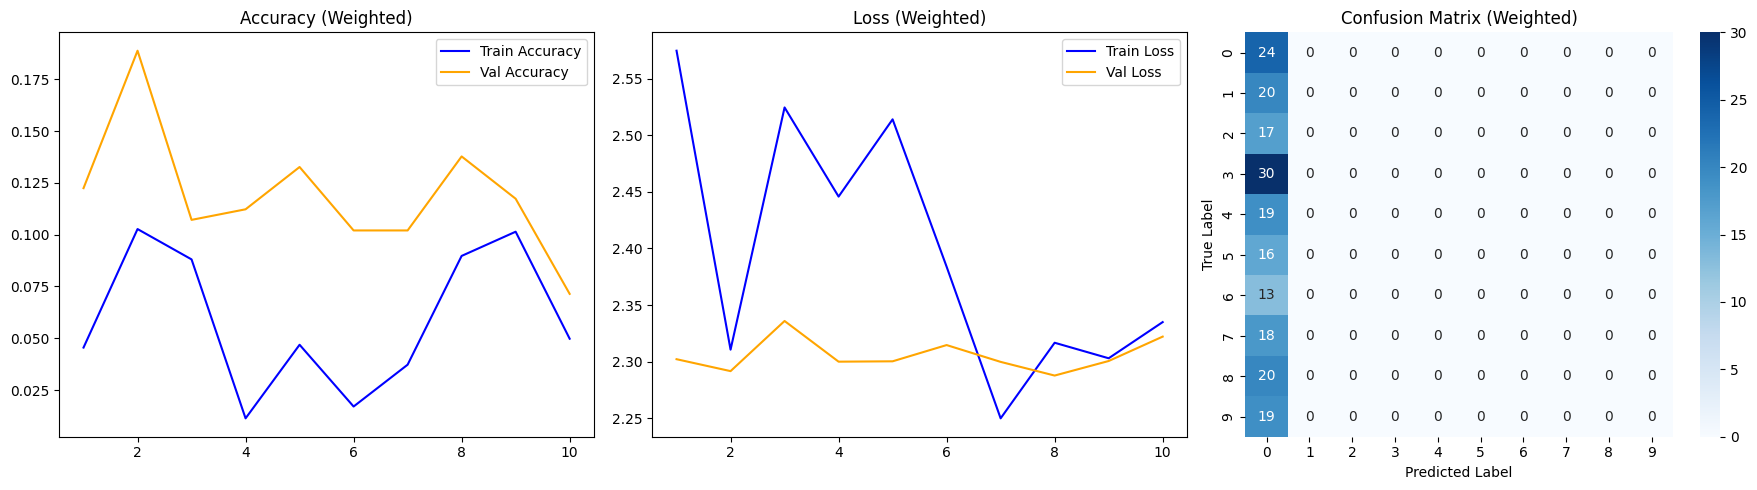

In [144]:
import time
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("--- EXPERIMENT 6: The Danger of Class Imbalance ---")

# Using our Champion Architecture (256 Neurons + 0.2 Dropout)
model_exp4 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model_exp4.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
# CRITICAL: Notice we are using `imbalanced_train_ds` here!
history_exp4 = model_exp4.fit(imbalanced_train_ds, validation_data=val_ds, epochs=10, verbose=1)
elapsed_time = time.time() - start_time

print(f"\n⏱️ Exp 6 Elapsed Training Time: {elapsed_time:.2f} seconds")
print(f"🏆 Exp 6 Peak Val Accuracy: {max(history_exp4.history['val_accuracy']):.4f}")

# Plot the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_exp4.history['accuracy'], label='Train')
ax1.plot(history_exp4.history['val_accuracy'], label='Validation')
ax1.set_title('Exp 5 Accuracy (Imbalanced Data)')
ax1.legend()

ax2.plot(history_exp4.history['loss'], label='Train')
ax2.plot(history_exp4.history['val_loss'], label='Validation')
ax2.set_title('Exp 5 Loss (Imbalanced Data)')
ax2.legend()
plt.show()

--- EVALUATING THE IMBALANCED MODEL ---
7/7 [==============================] - 1s 46ms/step


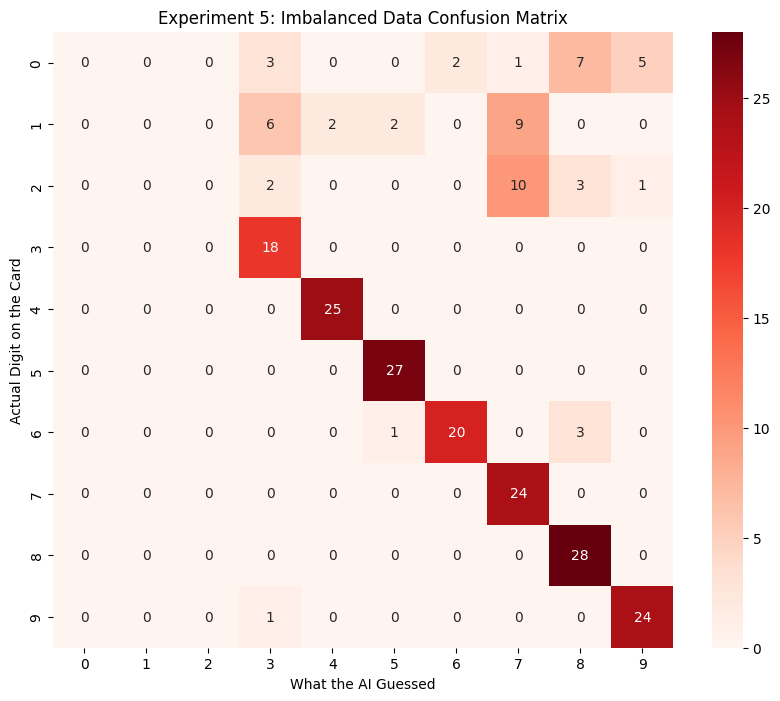

In [142]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("--- EVALUATING THE IMBALANCED MODEL ---")

# Have the broken Imbalanced Model guess the answers on the Test Set
predictions_exp4 = model_exp4.predict(test_images)
test_predictions_exp4 = np.argmax(predictions_exp4, axis=1)

# Generate the Matrix
cm_exp4 = confusion_matrix(test_true_labels, test_predictions_exp4)

# Plot it beautifully
plt.figure(figsize=(10, 8))
sns.heatmap(cm_exp4, annot=True, fmt='d', cmap='Reds', # Using Red to show it's the "Bad" model!
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Experiment 5: Imbalanced Data Confusion Matrix')
plt.ylabel('Actual Digit on the Card')
plt.xlabel('What the AI Guessed')
plt.show()

In [143]:
import time
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("--- EXPERIMENT 6 (Part B): Fixing Imbalance with GENTLER Class Weights ---")

# 1. Gentler penalty weights (5x instead of 10x)
penalty_weights = {
    0: 5.0, 1: 5.0, 2: 5.0,
    3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0
}

# 2. Build a fresh Champion model
model_exp4_weighted = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

# 3. CRITICAL FIX: Slower learning rate (0.0001) so the weights don't shock the system
model_exp4_weighted.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Train on the BROKEN dataset using the GENTLER WEIGHTS
start_time = time.time()
history_weighted = model_exp4_weighted.fit(
    imbalanced_train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=penalty_weights,
    verbose=1
)
elapsed_time = time.time() - start_time
print(f"\n⏱️ Weighted Model Training Time: {elapsed_time:.2f} seconds")

# 5. Generate the new Confusion Matrix on the Test Set
print("\nGenerating the Weighted Confusion Matrix...")
predictions_weighted = model_exp4_weighted.predict(test_images)
test_predictions_weighted = np.argmax(predictions_weighted, axis=1)
cm_weighted = confusion_matrix(test_true_labels, test_predictions_weighted)

# Plot it in Green
plt.figure(figsize=(10, 8))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Experiment 6: HEALED with Gentler Class Weights')
plt.ylabel('Actual Digit on the Card')
plt.xlabel('What the AI Guessed')
plt.show()

--- EXPERIMENT 6 (Part C): Fixing Imbalance with Lower Learning Rate ---



🚀 Starting Training with Adjusted Learning Rate...


NameError: name 'class_weights' is not defined